<a href="https://colab.research.google.com/github/Snjkmr162/The_Pricing_Analytics_Toolkit/blob/main/notebooks/week3_dashboard/Week3_Price_Volume_Margin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()  # upload kaggle.json when prompted
os.makedirs('/root/.kaggle', exist_ok=True)

Saving kaggle.json to kaggle.json


In [3]:
kaggle_files = glob.glob('/content/kaggle*.json')
print(f"Found: {kaggle_files}")
!cp "{kaggle_files[0]}" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

Found: ['/content/kaggle.json']


In [4]:
!pip install -q kaggle
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d walmart_data
!unzip -o walmart_data/train.csv.zip -d walmart_data
!unzip -o walmart_data/test.csv.zip -d walmart_data
!unzip -o walmart_data/features.csv.zip -d walmart_data

100% 2.70M/2.70M [00:00<00:00, 107MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: walmart_data/features.csv.zip  
  inflating: walmart_data/sampleSubmission.csv.zip  
  inflating: walmart_data/stores.csv  
  inflating: walmart_data/test.csv.zip  
  inflating: walmart_data/train.csv.zip  
Archive:  walmart_data/train.csv.zip
  inflating: walmart_data/train.csv  
Archive:  walmart_data/test.csv.zip
  inflating: walmart_data/test.csv   
Archive:  walmart_data/features.csv.zip
  inflating: walmart_data/features.csv  


In [5]:
train = pd.read_csv("walmart_data/train.csv", parse_dates=["Date"])
features = pd.read_csv("walmart_data/features.csv", parse_dates=["Date"])
stores = pd.read_csv("walmart_data/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

print(f"Data loaded: {df.shape}")
print(df.head(3))

Data loaded: (421570, 16)
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  151315  
2         8.106    A  151315  


In [6]:
# We'll use Store 1 across all departments as our base since we know it well from Weeks 1 and 2
store1 = df[df["Store"] == 1].copy()

top_depts = (store1.groupby("Dept")["Weekly_Sales"]
             .sum()
             .sort_values(ascending=False)
             .head(5)
             .index.tolist())

print(f"Top 5 departments by total sales in Store 1: {top_depts}")

store1_top = store1[store1["Dept"].isin(top_depts)].copy()
store1_top = store1_top.sort_values(["Dept", "Date"]).reset_index(drop=True)

print(f"\nRows in working dataset: {store1_top.shape[0]}")
print(f"Date range: {store1_top['Date'].min().date()} to {store1_top['Date'].max().date()}")

Top 5 departments by total sales in Store 1: [92, 95, 90, 38, 93]

Rows in working dataset: 715
Date range: 2010-02-05 to 2012-10-26


In [7]:
def build_pvm_dataset(df_subset, base_price=50, cogs_pct=0.60):
    """
    Build a Price-Volume-Margin dataset from Walmart sales data.

    Assumptions (all documented):
    - Price: derived from normalized sales (inverse relationship)
    - Volume: implied units = weekly_sales / own_price
    - COGS: 60% of price (standard retail gross margin assumption)
    - Gross Margin: (price - cost) * volume
    """
    result = df_subset.copy()

    # Derive price per department (normalize within each dept)
    result["own_price"] = result.groupby("Dept")["Weekly_Sales"].transform(
        lambda x: base_price * (1.2 - 0.4 * (x - x.min()) / (x.max() - x.min() + 1e-9))
    )

    # Derive volume (implied units sold)
    result["volume"] = result["Weekly_Sales"] / result["own_price"]

    # Derive margin components
    result["cost_per_unit"] = result["own_price"] * cogs_pct
    result["gross_margin_per_unit"] = result["own_price"] - result["cost_per_unit"]
    result["total_gross_margin"] = result["gross_margin_per_unit"] * result["volume"]
    result["margin_pct"] = (1 - cogs_pct) * 100  # 40% for all, by assumption

    return result

pvm_df = build_pvm_dataset(store1_top)

print("Documented assumptions:")
print("  Price:  derived from normalized weekly sales (inverse, $40-$60 range)")
print("  Volume: implied units = Weekly_Sales / own_price")
print("  COGS:   60% of price (standard retail gross margin assumption)")
print("  Margin: 40% gross margin (1 - COGS%)\n")

print("PVM dataset summary by department:")
summary = pvm_df.groupby("Dept").agg(
    Avg_Price=("own_price", "mean"),
    Avg_Volume=("volume", "mean"),
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Avg_Gross_Margin=("total_gross_margin", "mean")
).round(2)
print(summary.to_string())

Documented assumptions:
  Price:  derived from normalized weekly sales (inverse, $40-$60 range)
  Volume: implied units = Weekly_Sales / own_price
  COGS:   60% of price (standard retail gross margin assumption)
  Margin: 40% gross margin (1 - COGS%)

PVM dataset summary by department:
      Avg_Price  Avg_Volume  Avg_Weekly_Sales  Avg_Gross_Margin
Dept                                                           
38        53.32     1523.59          79978.22          31991.29
90        53.94     1545.15          82427.55          32971.02
92        53.40     2573.49         135458.97          54183.59
93        52.25     1396.92          71699.18          28679.67
95        50.11     2438.35         120772.06          48308.82


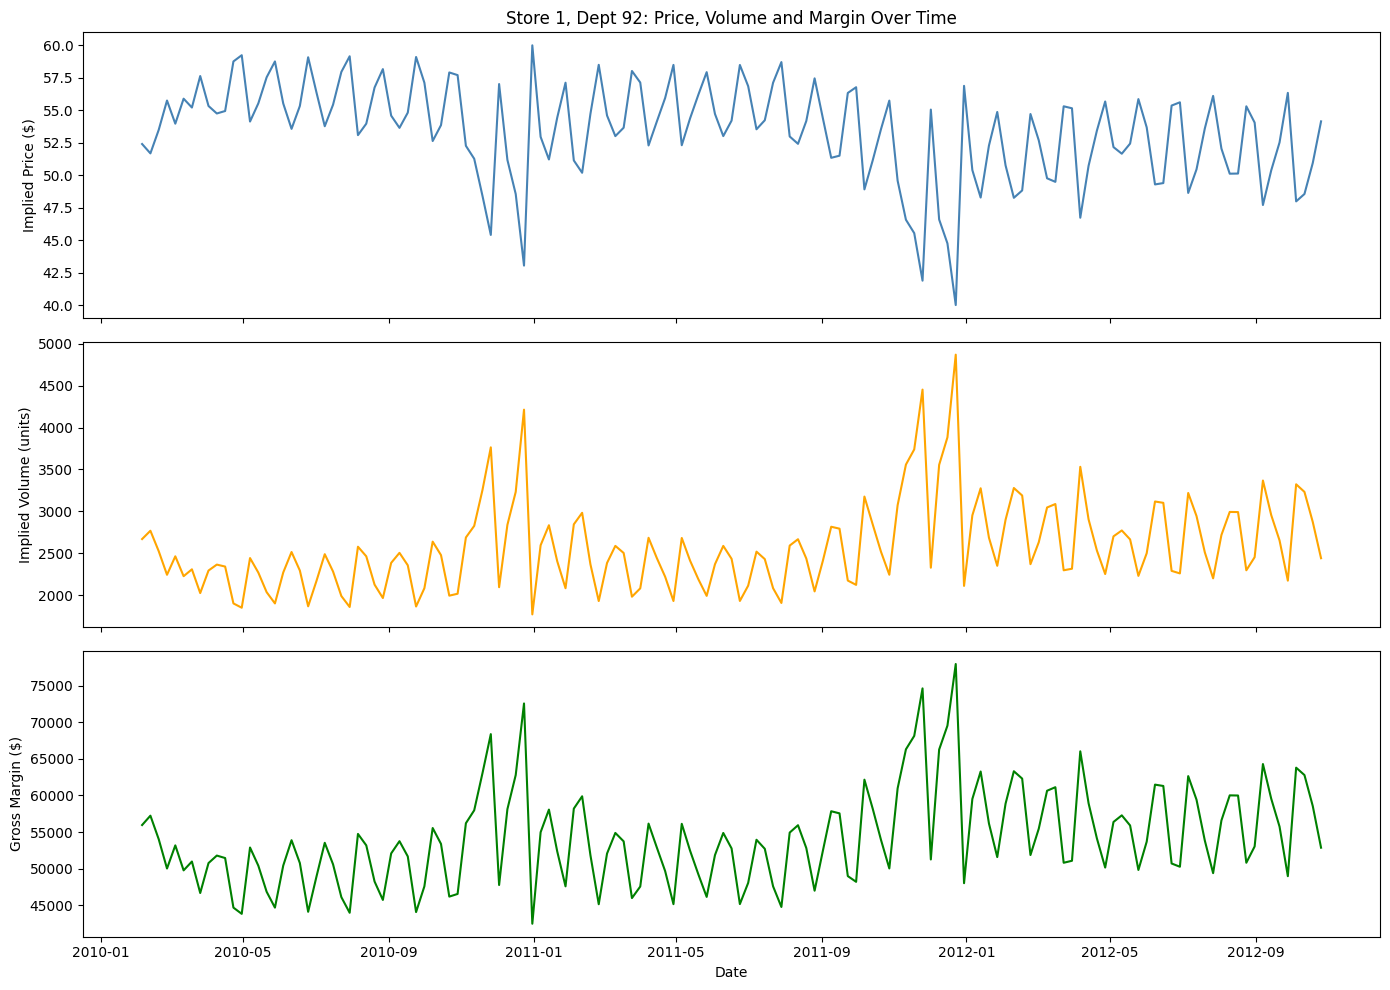

In [8]:
# Use the highest sales department as the showcase
top_dept = top_depts[0]
dept_data = pvm_df[pvm_df["Dept"] == top_dept].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dept_data["Date"], dept_data["own_price"],
             color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Implied Price ($)")
axes[0].set_title(f"Store 1, Dept {top_dept}: Price, Volume and Margin Over Time")

axes[1].plot(dept_data["Date"], dept_data["volume"],
             color="orange", linewidth=1.5)
axes[1].set_ylabel("Implied Volume (units)")

axes[2].plot(dept_data["Date"], dept_data["total_gross_margin"],
             color="green", linewidth=1.5)
axes[2].set_ylabel("Gross Margin ($)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("week3_day11_pvm_base.png", dpi=150)
plt.show()

In [9]:
# We test a range of elasticity assumptions since we can't calculate true elasticity from this dataset
elasticity_scenarios = {
    "Inelastic (-0.5)":       -0.5,
    "Moderate (-1.0)":        -1.0,
    "Standard (-1.5)":        -1.5,
    "Elastic (-2.0)":         -2.0,
    "Highly Elastic (-2.5)":  -2.5
}

# Base case: Dept 92 average price and volume
base_price = pvm_df[pvm_df["Dept"] == 92]["own_price"].mean()
base_volume = pvm_df[pvm_df["Dept"] == 92]["volume"].mean()
cogs_pct = 0.60

print(f"Base case (Dept 92):")
print(f"  Avg price:  ${base_price:.2f}")
print(f"  Avg volume: {base_volume:.0f} units/week")
print(f"  COGS:       {cogs_pct:.0%}")
print(f"  Base margin: ${base_price * (1 - cogs_pct) * base_volume:,.0f}/week\n")

# Simulate price changes from -20% to +20% in 5% steps
price_changes = [-0.20, -0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15, 0.20]

rows = []
for scenario, elasticity in elasticity_scenarios.items():
    for pct_change in price_changes:
        new_price = base_price * (1 + pct_change)
        new_volume = base_volume * (1 + elasticity * pct_change)
        new_volume = max(new_volume, 0)
        new_revenue = new_price * new_volume
        new_margin = new_price * (1 - cogs_pct) * new_volume
        rows.append({
            "Scenario": scenario,
            "Elasticity": elasticity,
            "Price_Change_Pct": pct_change * 100,
            "New_Price": new_price,
            "New_Volume": new_volume,
            "New_Revenue": new_revenue,
            "New_Margin": new_margin,
            "Margin_vs_Base": new_margin - (base_price * (1 - cogs_pct) * base_volume)
        })

elasticity_df = pd.DataFrame(rows)
print("Sample output (Standard elasticity -1.5):")
print(elasticity_df[elasticity_df["Scenario"] == "Standard (-1.5)"][
    ["Price_Change_Pct", "New_Price", "New_Volume", "New_Revenue", "New_Margin"]
].round(2).to_string(index=False))

Base case (Dept 92):
  Avg price:  $53.40
  Avg volume: 2573 units/week
  COGS:       60%
  Base margin: $54,969/week

Sample output (Standard elasticity -1.5):
 Price_Change_Pct  New_Price  New_Volume  New_Revenue  New_Margin
            -20.0      42.72     3345.54    142918.83    57167.53
            -15.0      45.39     3152.53    143090.61    57236.24
            -10.0      48.06     2959.51    142231.72    56892.69
             -5.0      50.73     2766.50    140342.17    56136.87
              0.0      53.40     2573.49    137421.95    54968.78
              5.0      56.07     2380.48    133471.07    53388.43
             10.0      58.74     2187.47    128489.52    51395.81
             15.0      61.41     1994.45    122477.31    48990.93
             20.0      64.08     1801.44    115434.44    46173.78


In [10]:
optimal_prices = []

for scenario, elasticity in elasticity_scenarios.items():
    scenario_df = elasticity_df[elasticity_df["Scenario"] == scenario]
    best_row = scenario_df.loc[scenario_df["New_Margin"].idxmax()]
    optimal_prices.append({
        "Scenario": scenario,
        "Elasticity": elasticity,
        "Optimal_Price_Change": best_row["Price_Change_Pct"],
        "Optimal_Price": best_row["New_Price"],
        "Optimal_Margin": best_row["New_Margin"],
        "Margin_vs_Base": best_row["Margin_vs_Base"]
    })

optimal_df = pd.DataFrame(optimal_prices)
print("Optimal price point by elasticity scenario:")
print(optimal_df[["Scenario", "Optimal_Price_Change",
                   "Optimal_Price", "Optimal_Margin",
                   "Margin_vs_Base"]].round(2).to_string(index=False))

Optimal price point by elasticity scenario:
             Scenario  Optimal_Price_Change  Optimal_Price  Optimal_Margin  Margin_vs_Base
     Inelastic (-0.5)                  20.0          64.08        59366.28         4397.50
      Moderate (-1.0)                   0.0          53.40        54968.78            0.00
      Standard (-1.5)                 -15.0          45.39        57236.24         2267.46
       Elastic (-2.0)                 -20.0          42.72        61565.03         6596.25
Highly Elastic (-2.5)                 -20.0          42.72        65962.54        10993.76


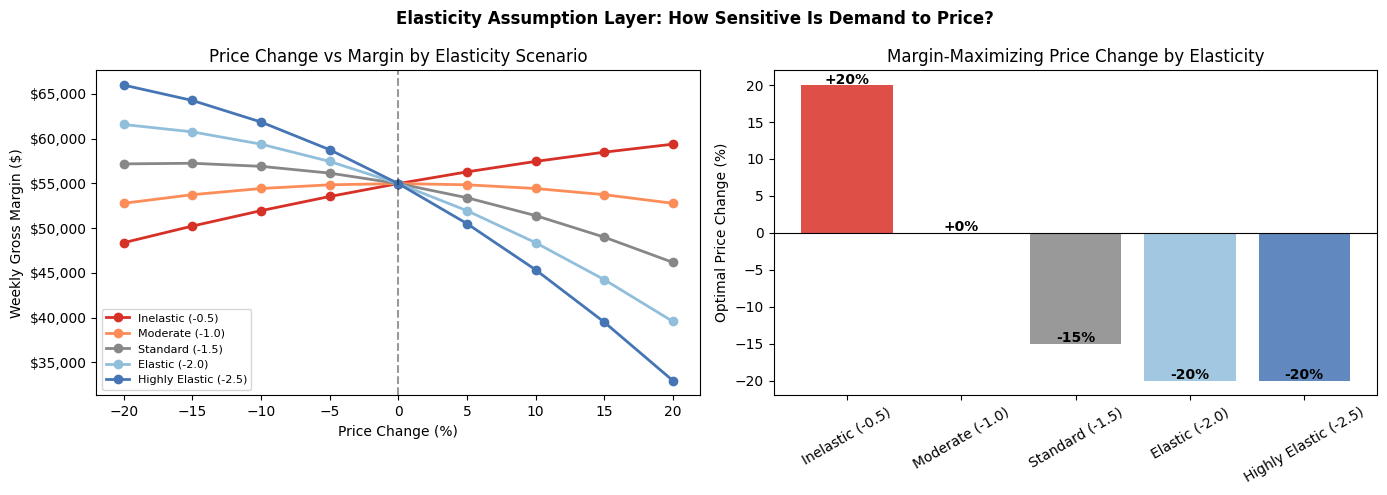

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#d73027", "#fc8d59", "#878787", "#91bfdb", "#4575b4"]

# Left: price change vs margin under different elasticity assumptions
for (scenario, elasticity), color in zip(elasticity_scenarios.items(), colors):
    subset = elasticity_df[elasticity_df["Scenario"] == scenario]
    axes[0].plot(subset["Price_Change_Pct"], subset["New_Margin"],
                 marker="o", label=scenario, color=color, linewidth=2)

axes[0].axvline(x=0, color="black", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Price Change (%)")
axes[0].set_ylabel("Weekly Gross Margin ($)")
axes[0].set_title("Price Change vs Margin by Elasticity Scenario")
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))

# Right: optimal price change per scenario
bars = axes[1].bar(optimal_df["Scenario"],
                   optimal_df["Optimal_Price_Change"],
                   color=colors, alpha=0.85)
axes[1].set_ylabel("Optimal Price Change (%)")
axes[1].set_title("Margin-Maximizing Price Change by Elasticity")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(y=0, color="black", linewidth=0.8)
for bar, val in zip(bars, optimal_df["Optimal_Price_Change"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{val:+.0f}%", ha="center", fontweight="bold")

plt.suptitle("Elasticity Assumption Layer: How Sensitive Is Demand to Price?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("week3_day12_elasticity.png", dpi=150)
plt.show()